# Module 3: CLAP — Connecting Audio and Language

> *"The encoder's job is to compress audio into a vector. CLAP's job is to make that vector mean something — in the same language the LLM speaks."*

This is Module 3 of the Audio Flamingo 3 series.

**The problem:** After Module 2, we have a 1280-dim audio embedding per time step. But 1280 random numbers don't mean anything to a language model. We need a way to **align** audio and text in the same semantic space.

**The solution:** CLAP — Contrastive Language-Audio Pretraining. Train an audio encoder and a text encoder so that matching pairs (audio + its description) end up near each other in embedding space, and non-matching pairs end up far apart.

**What we'll build:**
1. The geometric intuition — what "same embedding space" means
2. A toy text encoder (learned word embeddings)
3. A nano audio encoder (our Module 2 encoder, shrunk further)
4. The contrastive loss (InfoNCE) from scratch
5. A mini CLAP training loop on 20 synthetic audio+text pairs
6. Visualizing the embedding space before and after training
7. Zero-shot audio classification with our trained CLAP
8. How AF-CLAP → AF-Whisper: what changed in AF3

**No pretrained weights. No HuggingFace. ~150 lines of PyTorch.**

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
from collections import defaultdict

plt.style.use('dark_background')
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device: cpu
PyTorch: 2.10.0+cpu


---
## Part 1: The Geometric Intuition

Before writing a single line of model code, let's understand **what we're trying to achieve geometrically**.

Imagine a 2D plane. Every audio clip and every text description is a point on this plane.

**Before CLAP training:** points are scattered randomly. "Dog barking" audio and "a dog barking" text are nowhere near each other.

**After CLAP training:** matching pairs cluster together. You could drop a new audio clip anywhere, and the nearest text point would correctly describe it — **zero-shot classification**.

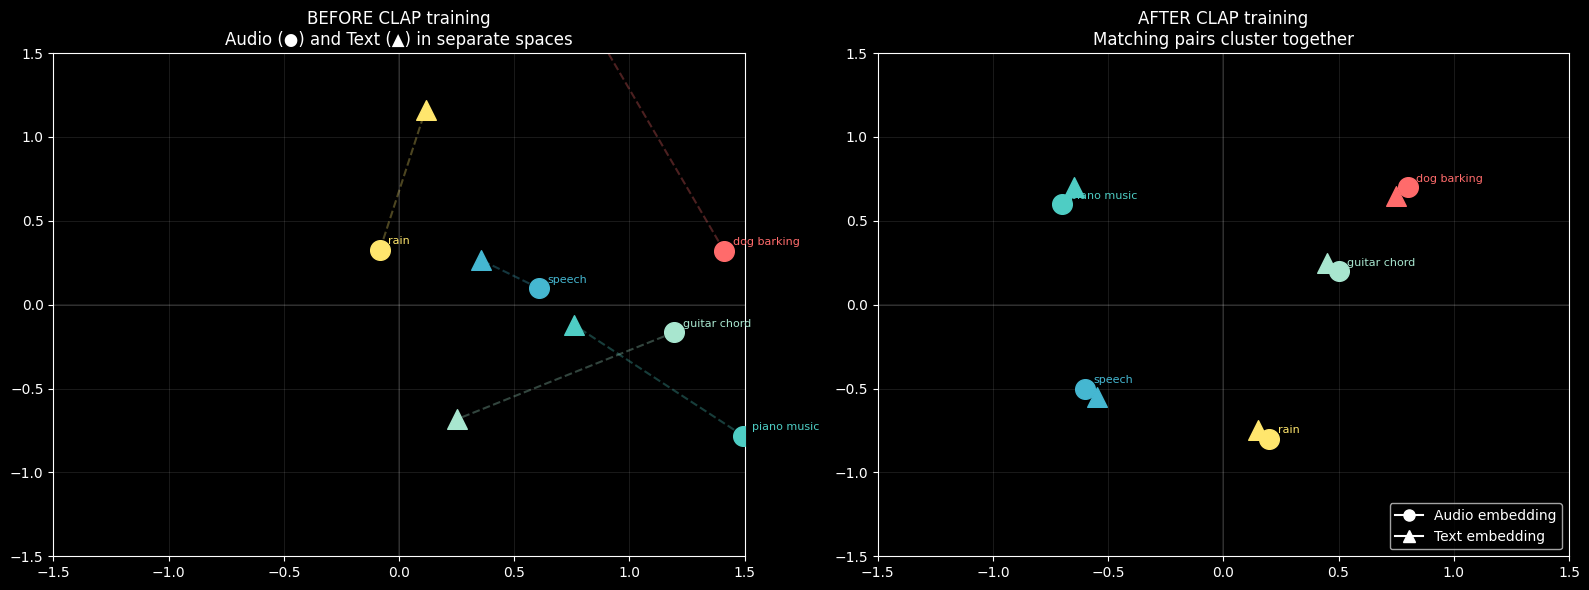

This is the goal: same concept → nearby points.
CLAP achieves this with a contrastive loss — the model learns by comparison.


In [2]:
  # --- Visualize the goal ---

# 5 audio-text concept pairs we want to align
concepts = {
    'dog barking':    {'audio': [0.8, 0.7],  'text': [0.75, 0.65]},
    'piano music':    {'audio': [-0.7, 0.6], 'text': [-0.65, 0.7]},
    'rain':           {'audio': [0.2, -0.8], 'text': [0.15, -0.75]},
    'speech':         {'audio': [-0.6, -0.5],'text': [-0.55, -0.55]},
    'guitar chord':   {'audio': [0.5, 0.2],  'text': [0.45, 0.25]},
}
colors = ['#FF6B6B', '#4ECDC4', '#FFE66D', '#45B7D1', '#A8E6CF']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BEFORE: random
rng = np.random.RandomState(0)
for i, (concept, pts) in enumerate(concepts.items()):
    a = rng.randn(2) * 0.8
    t = rng.randn(2) * 0.8
    axes[0].scatter(*a, s=200, color=colors[i], marker='o', zorder=3)
    axes[0].scatter(*t, s=200, color=colors[i], marker='^', zorder=3)
    axes[0].plot([a[0], t[0]], [a[1], t[1]], '--', color=colors[i], alpha=0.3, lw=1.5)
    axes[0].annotate(concept, a, textcoords='offset points', xytext=(6,4),
                     fontsize=8, color=colors[i])

axes[0].set_title('BEFORE CLAP training\nAudio (●) and Text (▲) in separate spaces', fontsize=12)
axes[0].set_xlim(-1.5, 1.5); axes[0].set_ylim(-1.5, 1.5)
axes[0].axhline(0, color='white', alpha=0.1); axes[0].axvline(0, color='white', alpha=0.1)
axes[0].grid(alpha=0.1)

# AFTER: aligned
for i, (concept, pts) in enumerate(concepts.items()):
    a, t = pts['audio'], pts['text']
    axes[1].scatter(*a, s=200, color=colors[i], marker='o', zorder=3)
    axes[1].scatter(*t, s=200, color=colors[i], marker='^', zorder=3)
    axes[1].plot([a[0], t[0]], [a[1], t[1]], '--', color=colors[i], alpha=0.4, lw=1.5)
    axes[1].annotate(concept, a, textcoords='offset points', xytext=(6,4),
                     fontsize=8, color=colors[i])

axes[1].set_title('AFTER CLAP training\nMatching pairs cluster together', fontsize=12)
axes[1].set_xlim(-1.5, 1.5); axes[1].set_ylim(-1.5, 1.5)
axes[1].axhline(0, color='white', alpha=0.1); axes[1].axvline(0, color='white', alpha=0.1)
axes[1].grid(alpha=0.1)

from matplotlib.lines import Line2D
legend = [Line2D([0],[0], marker='o', color='w', markersize=8, label='Audio embedding'),
          Line2D([0],[0], marker='^', color='w', markersize=8, label='Text embedding')]
axes[1].legend(handles=legend, loc='lower right')

plt.tight_layout()
plt.show()

print('This is the goal: same concept → nearby points.')
print('CLAP achieves this with a contrastive loss — the model learns by comparison.')

---
## Part 2: Synthetic Audio Dataset

We'll create 5 audio "concepts" as synthetic signals — each with a distinct character — and pair each with a text description. This gives us a tiny but real training set.

Dataset: 20 audio clips across 5 concepts
Concepts: ['low rumble', 'high whistle', 'piano chord', 'white noise', 'rising sweep']
Mel shape per clip: (80, 98)


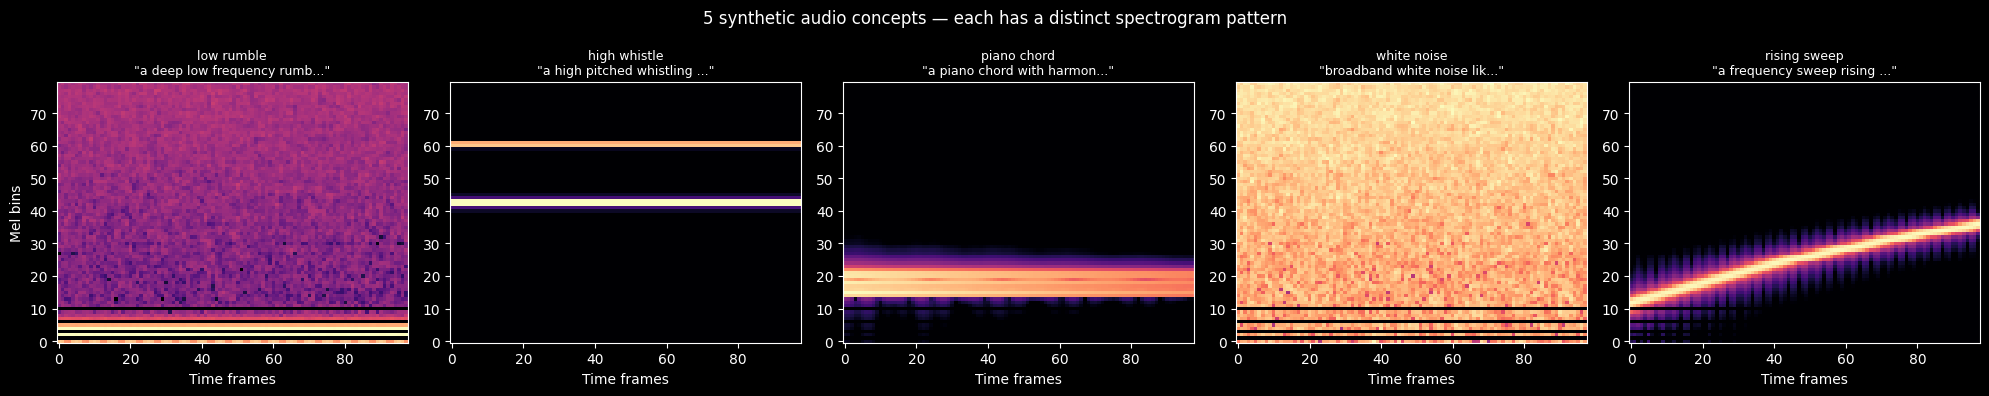

In [3]:
# --- Audio preprocessing from Module 1 ---

def hz_to_mel(hz):
    return 2595.0 * np.log10(1.0 + hz / 700.0)

def mel_to_hz(mel):
    return 700.0 * (10.0 ** (mel / 2595.0) - 1.0)

def build_mel_filterbank(n_mels, n_fft, sample_rate):
    fmax = sample_rate / 2.0
    mel_points = np.linspace(hz_to_mel(0), hz_to_mel(fmax), n_mels + 2)
    hz_points  = mel_to_hz(mel_points)
    n_freqs    = n_fft // 2 + 1
    bin_points = np.floor((n_fft + 1) * hz_points / sample_rate).astype(int)
    filterbank = np.zeros((n_mels, n_freqs))
    for m in range(1, n_mels + 1):
        fl, fc, fr = bin_points[m-1], bin_points[m], bin_points[m+1]
        for k in range(fl, fc):
            filterbank[m-1, k] = (k - fl) / (fc - fl + 1e-8)
        for k in range(fc, fr):
            filterbank[m-1, k] = (fr - k) / (fr - fc + 1e-8)
    return filterbank

def log_mel_spectrogram(audio, sample_rate=16000, n_fft=400, hop_length=160, n_mels=80):
    window   = np.hanning(n_fft)
    n_frames = 1 + (len(audio) - n_fft) // hop_length
    n_freqs  = n_fft // 2 + 1
    power_spec = np.zeros((n_freqs, n_frames))
    for i in range(n_frames):
        start = i * hop_length
        frame = audio[start:start+n_fft] * window
        power_spec[:, i] = np.abs(np.fft.rfft(frame)) ** 2
    filterbank = build_mel_filterbank(n_mels, n_fft, sample_rate)
    mel_spec   = filterbank @ power_spec
    log_spec   = np.log10(np.maximum(mel_spec, 1e-10))
    log_spec   = np.maximum(log_spec, log_spec.max() - 8.0)
    log_spec   = (log_spec + 4.0) / 4.0
    return log_spec


# --- 5 synthetic audio concepts ---
SR = 16_000
DURATION = 1.0   # 1 second per clip (short = fast to process)
t = np.linspace(0, DURATION, int(SR * DURATION), endpoint=False)

def make_audio_clips():
    clips = {}

    # 1. Low rumble — like thunder or a bass drum
    clips['low rumble'] = 0.6 * np.sin(2*np.pi*60*t) + 0.3 * np.random.randn(len(t)) * 0.05

    # 2. High whistle — like a bird or a flute
    clips['high whistle'] = 0.7 * np.sin(2*np.pi*2000*t) + 0.2 * np.sin(2*np.pi*4000*t)

    # 3. Piano chord — A major (440 + 554 + 659 Hz)
    clips['piano chord'] = (0.4 * np.sin(2*np.pi*440*t) +
                            0.3 * np.sin(2*np.pi*554*t) +
                            0.3 * np.sin(2*np.pi*659*t)) * np.exp(-2*t)

    # 4. White noise — like rain or static
    clips['white noise'] = np.random.randn(len(t)) * 0.3

    # 5. Rising sweep — like a siren or alarm
    freq_sweep = np.linspace(300, 1500, len(t))
    clips['rising sweep'] = 0.6 * np.sin(2*np.pi * np.cumsum(freq_sweep) / SR)

    return clips

# Each concept gets 4 variations (augmented) → 20 total training pairs
def augment(audio, rng):
    """Simple augmentations: volume + small noise"""
    volume = rng.uniform(0.7, 1.0)
    noise  = rng.randn(len(audio)) * 0.01
    return audio * volume + noise

clips = make_audio_clips()
concept_names = list(clips.keys())

# Text descriptions for each concept
text_descriptions = {
    'low rumble':    'a deep low frequency rumble sound',
    'high whistle':  'a high pitched whistling tone',
    'piano chord':   'a piano chord with harmonic tones',
    'white noise':   'broadband white noise like static or rain',
    'rising sweep':  'a frequency sweep rising from low to high',
}

# Build the dataset: 20 (audio, text_label) pairs
rng = np.random.RandomState(42)
dataset = []
for concept, audio in clips.items():
    for _ in range(4):   # 4 augmentations per concept
        aug = augment(audio, rng)
        mel = log_mel_spectrogram(aug)   # (80, T)
        dataset.append((mel, concept))   # (spectrogram, concept_name)

print(f'Dataset: {len(dataset)} audio clips across {len(concept_names)} concepts')
print(f'Concepts: {concept_names}')
print(f'Mel shape per clip: {dataset[0][0].shape}')

# Visualize the 5 spectrograms
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (concept, audio) in enumerate(clips.items()):
    mel = log_mel_spectrogram(audio)
    axes[i].imshow(mel, aspect='auto', origin='lower', cmap='magma')
    axes[i].set_title(f'{concept}\n"{text_descriptions[concept][:25]}..."', fontsize=9)
    axes[i].set_xlabel('Time frames')
    if i == 0: axes[i].set_ylabel('Mel bins')
plt.suptitle('5 synthetic audio concepts — each has a distinct spectrogram pattern', fontsize=12)
plt.tight_layout()
plt.show()

---
## Part 3: The Two Encoders

CLAP has two encoders that must produce embeddings in the **same space**:
- **Audio encoder**: Mel spectrogram → 128-dim vector
- **Text encoder**: sentence → 128-dim vector

Both outputs are L2-normalized (projected onto the unit sphere). This makes the dot product equal to cosine similarity — a clean measure of semantic distance.

In [4]:
# --- Nano Audio Encoder ---
# Simplified from Module 2: Conv stem + global average pooling + MLP projection
# (No full transformer — CPU must be fast for training loop)

class NanoAudioEncoder(nn.Module):
    """
    Nano audio encoder for CLAP.

    Deliberately simple: we want to see learning happen, not wait for it.
    The architecture principle is the same as AF-Whisper:
      Conv features → Pool over time → Project to shared embedding space

    Input:  (batch, n_mels, time)  e.g. (20, 80, 97)
    Output: (batch, embed_dim)     e.g. (20, 128)  — L2 normalized
    """
    def __init__(self, n_mels: int = 80, embed_dim: int = 128):
        super().__init__()
        # Conv stem: extract features across mel bins and time
        self.conv1 = nn.Conv1d(n_mels, 256, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(256, 256, kernel_size=5, padding=2, stride=2)
        self.conv3 = nn.Conv1d(256, 256, kernel_size=3, padding=1)
        self.norm  = nn.LayerNorm(256)
        # Project to embedding space
        self.proj  = nn.Linear(256, embed_dim)

    def forward(self, mel: torch.Tensor) -> torch.Tensor:
        # mel: (B, n_mels, T)
        x = F.gelu(self.conv1(mel))    # (B, 256, T)
        x = F.gelu(self.conv2(x))      # (B, 256, T//2)
        x = F.gelu(self.conv3(x))      # (B, 256, T//2)
        # Global average pooling: collapse the time dimension
        # This gives one vector per audio clip, regardless of length
        x = x.mean(dim=-1)             # (B, 256)
        x = self.norm(x)
        x = self.proj(x)               # (B, embed_dim)
        # L2 normalize: project onto unit sphere
        # Now dot product = cosine similarity
        x = F.normalize(x, dim=-1)     # (B, embed_dim), ||x||=1
        return x


# --- Nano Text Encoder ---
# Bag-of-words with learned embeddings + MLP
# (Not a transformer — we don't have a real tokenizer here)

class NanoTextEncoder(nn.Module):
    """
    Nano text encoder for CLAP.

    In real CLAP this is a BERT or RoBERTa transformer.
    Here: bag-of-words embeddings → average → MLP → L2 normalize.
    Same principle, far simpler.

    Input:  (batch, seq_len)  — token indices
    Output: (batch, embed_dim) — L2 normalized
    """
    def __init__(self, vocab_size: int, embed_dim: int = 128, hidden: int = 256):
        super().__init__()
        # Word embedding table: each word → 128-dim vector
        self.word_embed = nn.Embedding(vocab_size, 128, padding_idx=0)
        # MLP projection
        self.fc1  = nn.Linear(128, hidden)
        self.fc2  = nn.Linear(hidden, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, tokens: torch.Tensor) -> torch.Tensor:
        # tokens: (B, seq_len)
        x = self.word_embed(tokens)      # (B, seq_len, 128)
        x = x.mean(dim=1)               # (B, 128) — average over words
        x = F.gelu(self.fc1(x))         # (B, hidden)
        x = self.norm(self.fc2(x))      # (B, embed_dim)
        x = F.normalize(x, dim=-1)      # (B, embed_dim), L2 normalized
        return x


# --- Simple tokenizer ---
# Build vocab from our 5 descriptions

all_words = set()
for desc in text_descriptions.values():
    all_words.update(desc.lower().split())
all_words = sorted(all_words)

word2idx = {'<PAD>': 0}
for w in all_words:
    word2idx[w] = len(word2idx)
VOCAB_SIZE = len(word2idx)

def tokenize(text: str, max_len: int = 12) -> torch.Tensor:
    words  = text.lower().split()[:max_len]
    ids    = [word2idx.get(w, 0) for w in words]
    ids   += [0] * (max_len - len(ids))   # pad
    return torch.tensor(ids, dtype=torch.long)

print(f'Vocabulary: {VOCAB_SIZE} words')
print(f'Words: {all_words}')
print()

# Test tokenizer
sample_text = text_descriptions['piano chord']
sample_tokens = tokenize(sample_text)
print(f'Text:   "{sample_text}"')
print(f'Tokens: {sample_tokens.tolist()}')

# Instantiate encoders
EMBED_DIM  = 128
audio_enc  = NanoAudioEncoder(n_mels=80, embed_dim=EMBED_DIM)
text_enc   = NanoTextEncoder(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM)

n_audio = sum(p.numel() for p in audio_enc.parameters())
n_text  = sum(p.numel() for p in text_enc.parameters())
print(f'\nAudio encoder params: {n_audio:,}')
print(f'Text encoder params:  {n_text:,}')
print(f'Total CLAP params:    {n_audio + n_text:,}  (real CLAP: ~150M)')

Vocabulary: 27 words
Words: ['a', 'broadband', 'chord', 'deep', 'frequency', 'from', 'harmonic', 'high', 'like', 'low', 'noise', 'or', 'piano', 'pitched', 'rain', 'rising', 'rumble', 'sound', 'static', 'sweep', 'to', 'tone', 'tones', 'whistling', 'white', 'with']

Text:   "a piano chord with harmonic tones"
Tokens: [1, 13, 3, 26, 7, 23, 0, 0, 0, 0, 0, 0]

Audio encoder params: 660,864
Text encoder params:  69,632
Total CLAP params:    730,496  (real CLAP: ~150M)


---
## Part 4: The Contrastive Loss (InfoNCE)

This is the heart of CLAP. Let's derive it from first principles.

**Setup:** In a batch of N pairs, we have:
- N audio embeddings: `A = [a₁, a₂, ..., aₙ]`
- N text embeddings:  `T = [t₁, t₂, ..., tₙ]`

Pair (aᵢ, tᵢ) is a **positive** — they describe the same sound. All other pairs (aᵢ, tⱼ where j≠i) are **negatives**.

**The similarity matrix:** `S[i,j] = dot(aᵢ, tⱼ)` — an N×N matrix.
- Diagonal = positive pairs (should be HIGH)
- Off-diagonal = negative pairs (should be LOW)

**InfoNCE loss:** treat each row as a classification problem. For audio embedding aᵢ, the "correct class" is column i (its matching text). Apply cross-entropy. Do the same for columns (text→audio). Average both directions.

The temperature τ (tau) controls how sharp the distribution is — lower τ = harder separation.

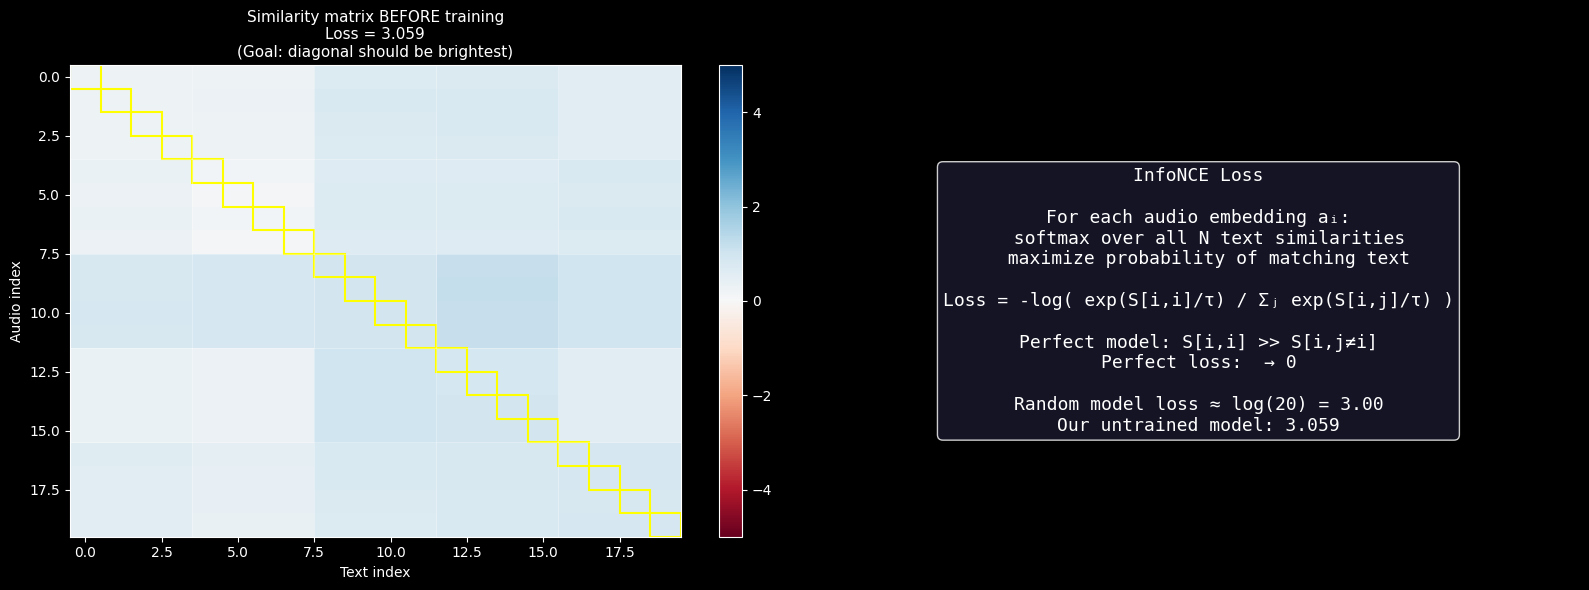

In [5]:
# --- InfoNCE Contrastive Loss ---

class InfoNCELoss(nn.Module):
    """
    Symmetric InfoNCE loss — used in CLIP, CLAP, and AF-CLAP.

    Given N audio embeddings and N text embeddings (one matching pair each):
    - Build N×N cosine similarity matrix
    - Audio→Text: each audio must identify its matching text (cross-entropy on rows)
    - Text→Audio: each text must identify its matching audio (cross-entropy on cols)
    - Loss = average of both directions

    Args:
        temperature: softmax temperature τ (learned or fixed, typically 0.07)
    """
    def __init__(self, temperature: float = 0.07):
        super().__init__()
        # Make temperature a learnable parameter (like CLIP does)
        self.log_temp = nn.Parameter(torch.tensor(math.log(temperature)))

    def forward(self, audio_emb: torch.Tensor, text_emb: torch.Tensor):
        """
        Args:
            audio_emb: (N, embed_dim) — L2 normalized audio embeddings
            text_emb:  (N, embed_dim) — L2 normalized text embeddings
        Returns:
            loss: scalar
            sim_matrix: (N, N) similarity matrix (for visualization)
        """
        N = audio_emb.shape[0]
        temp = self.log_temp.exp()  # always positive

        # Similarity matrix: S[i,j] = cos_sim(audio_i, text_j)
        # Since embeddings are L2-normalized, dot product = cosine similarity
        sim = torch.matmul(audio_emb, text_emb.T)  # (N, N)
        sim = sim / temp                             # scale by temperature

        # Ground truth: diagonal is correct (pair i matches pair i)
        labels = torch.arange(N, device=audio_emb.device)  # [0, 1, 2, ..., N-1]

        # Audio→Text: for each audio, find its matching text
        loss_a2t = F.cross_entropy(sim, labels)

        # Text→Audio: for each text, find its matching audio
        loss_t2a = F.cross_entropy(sim.T, labels)

        loss = (loss_a2t + loss_t2a) / 2.0
        return loss, sim.detach()


# --- Visualize: what the similarity matrix looks like before training ---

criterion = InfoNCELoss(temperature=0.07)

# Build batch: all 20 samples
mel_batch_all  = torch.stack([
    torch.tensor(mel, dtype=torch.float32)
    for mel, _ in dataset
])  # (20, 80, T)

text_batch_all = torch.stack([
    tokenize(text_descriptions[concept])
    for _, concept in dataset
])  # (20, 12)

with torch.no_grad():
    a_emb = audio_enc(mel_batch_all)   # (20, 128)
    t_emb = text_enc(text_batch_all)   # (20, 128)
    loss_before, sim_before = criterion(a_emb, t_emb)

labels_str = [c[:8] for _, c in dataset]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im = axes[0].imshow(sim_before.numpy(), cmap='RdBu', vmin=-5, vmax=5, aspect='auto')
axes[0].set_title(f'Similarity matrix BEFORE training\nLoss = {loss_before.item():.3f}\n'
                  f'(Goal: diagonal should be brightest)', fontsize=11)
axes[0].set_xlabel('Text index'); axes[0].set_ylabel('Audio index')
plt.colorbar(im, ax=axes[0])

# Mark the diagonal (correct pairs)
for i in range(20):
    axes[0].add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False,
                                     edgecolor='yellow', lw=1.5))

# Show concept blocks
for i, tick in enumerate(range(0, 20, 4)):
    axes[0].axhline(tick-0.5, color='white', alpha=0.3, lw=0.8)
    axes[0].axvline(tick-0.5, color='white', alpha=0.3, lw=0.8)

axes[1].text(0.5, 0.5,
    'InfoNCE Loss\n\n'
    'For each audio embedding aᵢ:\n'
    '  softmax over all N text similarities\n'
    '  maximize probability of matching text\n\n'
    'Loss = -log( exp(S[i,i]/τ) / Σⱼ exp(S[i,j]/τ) )\n\n'
    'Perfect model: S[i,i] >> S[i,j≠i]\n'
    'Perfect loss:  → 0\n\n'
    f'Random model loss ≈ log({20}) = {math.log(20):.2f}\n'
    f'Our untrained model: {loss_before.item():.3f}',
    transform=axes[1].transAxes, ha='center', va='center',
    fontsize=13, fontfamily='monospace',
    bbox=dict(boxstyle='round', facecolor='#1a1a2e', alpha=0.8))
axes[1].axis('off')

plt.tight_layout()
plt.show()

---
## Part 5: Training Loop

Now we train. Watch the loss drop and the similarity matrix's diagonal emerge.

In [6]:
# --- CLAP Training Loop ---

# Re-initialize fresh encoders
torch.manual_seed(0)
audio_enc = NanoAudioEncoder(n_mels=80, embed_dim=EMBED_DIM)
text_enc  = NanoTextEncoder(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM)
criterion = InfoNCELoss(temperature=0.07)

optimizer = torch.optim.AdamW(
    list(audio_enc.parameters()) +
    list(text_enc.parameters()) +
    list(criterion.parameters()),
    lr=3e-3,
    weight_decay=1e-4
)

N_EPOCHS = 300
loss_history = []
sim_snapshots = {}   # save similarity matrices at key epochs

print('Training NanoCLAP...')
print(f'{"Epoch":>6}  {"Loss":>8}  {"Temp":>6}  {"Diag Mean":>10}  {"Off-diag Mean":>14}')
print('-' * 60)

for epoch in range(1, N_EPOCHS + 1):
    audio_enc.train(); text_enc.train()

    # Full batch (all 20 pairs) — small dataset fits in memory
    a_emb = audio_enc(mel_batch_all)        # (20, 128)
    t_emb = text_enc(text_batch_all)        # (20, 128)
    loss, sim_matrix = criterion(a_emb, t_emb)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    # Save snapshots at key epochs
    if epoch in [1, 10, 50, 100, 200, 300]:
        sim_snapshots[epoch] = sim_matrix.clone()

    if epoch % 50 == 0 or epoch == 1:
        with torch.no_grad():
            diag_mean    = sim_matrix.diag().mean().item()
            offdiag_mean = (sim_matrix.sum() - sim_matrix.trace()).item() / (20*20 - 20)
            temp         = criterion.log_temp.exp().item()
        print(f'{epoch:>6}  {loss.item():>8.4f}  {temp:>6.4f}  '
              f'{diag_mean:>10.4f}  {offdiag_mean:>14.4f}')

print('\nTraining complete!')

Training NanoCLAP...
 Epoch      Loss    Temp   Diag Mean   Off-diag Mean
------------------------------------------------------------
     1    2.9876  0.0702     -1.1768         -1.2469
    50    1.5996  0.0721      7.3602          2.2434
   100    1.3873  0.0709     11.6824          0.4391
   150    1.3866  0.0707     12.0224          0.4337
   200    1.3865  0.0707     12.1381          0.3918
   250    1.3865  0.0706     12.2281          0.3501
   300    1.3865  0.0706     12.3037          0.3097

Training complete!


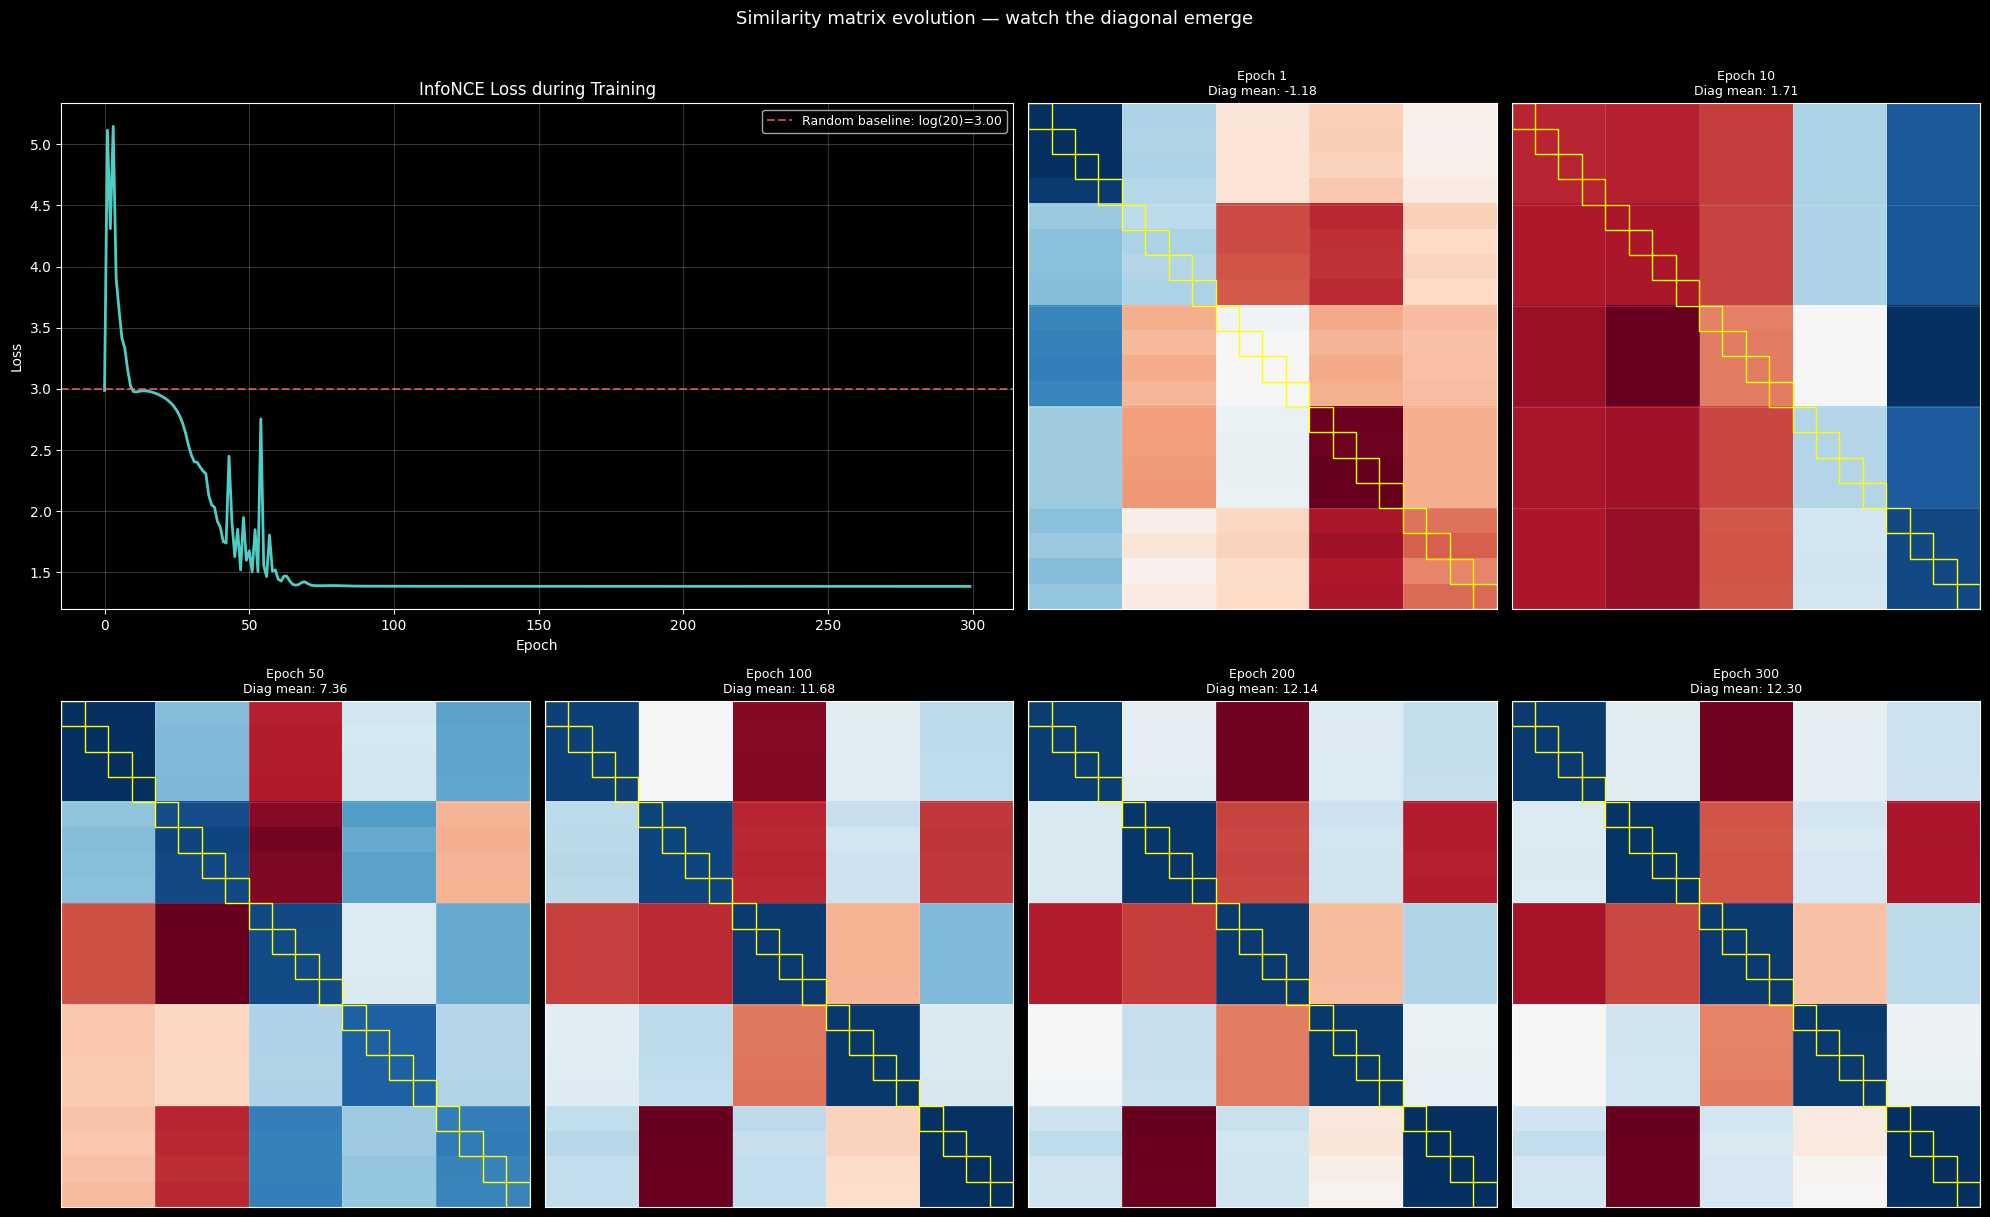

Key observation:
  Epoch 1:   Random matrix — no structure
  Epoch 50+: Diagonal starts to appear — matching pairs get high similarity
  Epoch 300: Clear diagonal — the model learned the audio-text alignment


In [7]:
# --- Visualize training progress ---

fig = plt.figure(figsize=(20, 12))

# Loss curve
ax_loss = fig.add_subplot(2, 4, (1, 2))
ax_loss.plot(loss_history, color='#4ECDC4', lw=2)
ax_loss.axhline(math.log(20), color='#FF6B6B', linestyle='--', alpha=0.7,
                label=f'Random baseline: log(20)={math.log(20):.2f}')
ax_loss.set_title('InfoNCE Loss during Training', fontsize=12)
ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
ax_loss.legend(fontsize=9); ax_loss.grid(alpha=0.2)

for snap_i, epoch in enumerate([1, 10, 50, 100, 200, 300]):
    ax = fig.add_subplot(2, 4, snap_i + 3)
    sim = sim_snapshots[epoch].numpy()
    ax.imshow(sim, cmap='RdBu', vmin=sim.min(), vmax=sim.max(), aspect='auto')
    for i in range(20):
        ax.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False,
                                    edgecolor='yellow', lw=1))
    for tick in range(0, 20, 4):
        ax.axhline(tick-0.5, color='white', alpha=0.2, lw=0.5)
        ax.axvline(tick-0.5, color='white', alpha=0.2, lw=0.5)
    diag = np.diag(sim).mean()
    ax.set_title(f'Epoch {epoch}\nDiag mean: {diag:.2f}', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Similarity matrix evolution — watch the diagonal emerge',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Key observation:')
print('  Epoch 1:   Random matrix — no structure')
print('  Epoch 50+: Diagonal starts to appear — matching pairs get high similarity')
print('  Epoch 300: Clear diagonal — the model learned the audio-text alignment')

---
## Part 6: Visualizing the Learned Embedding Space

After training, let's look at where audio and text embeddings live in space. We'll use PCA to project 128-dim embeddings to 2D.

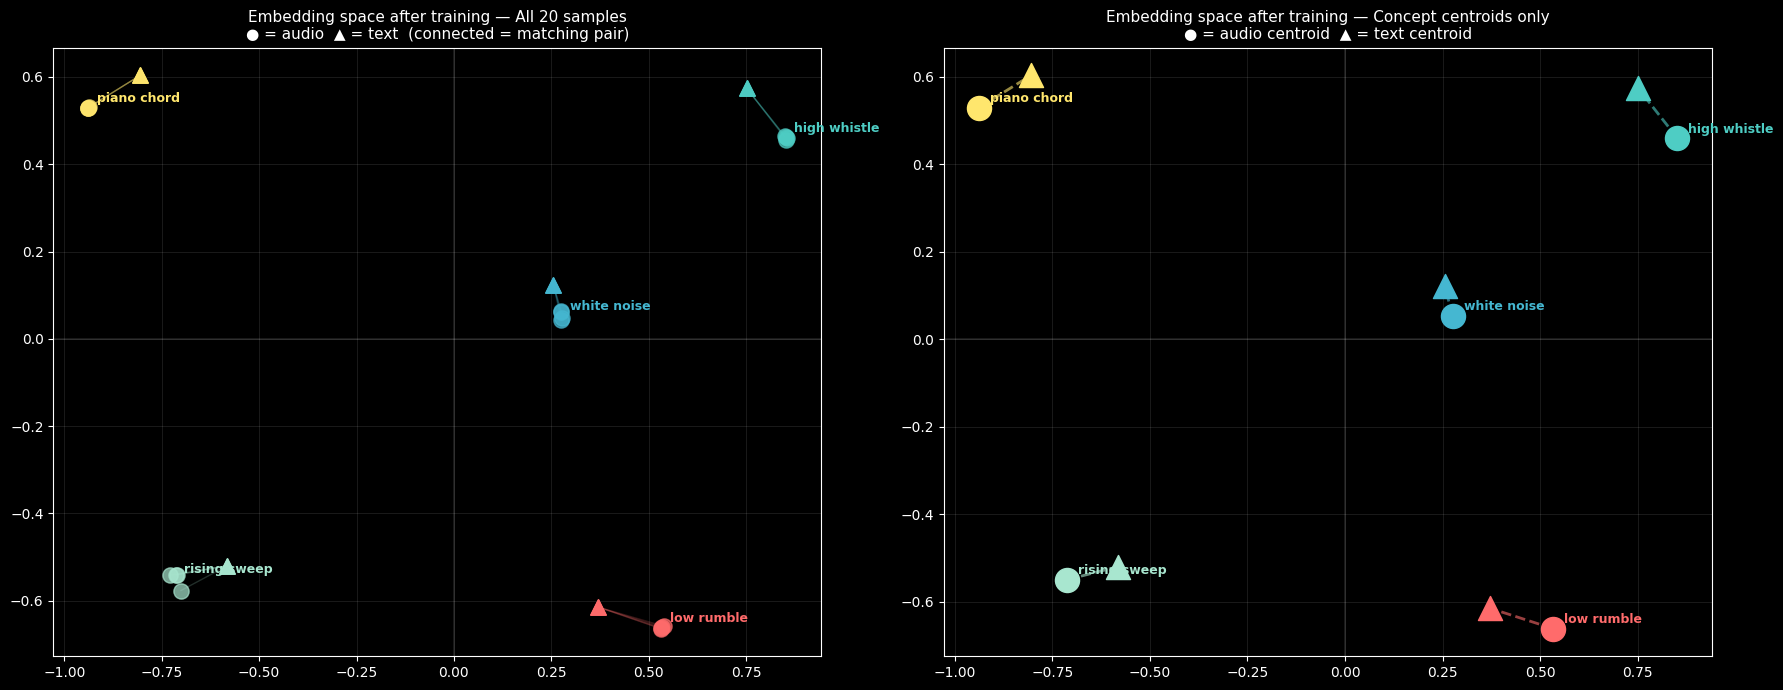

Each color = one concept.
Audio (●) and text (▲) of the same concept cluster together.
Different concepts are separated in space.
This is exactly what CLAP learns — a shared semantic space.


In [8]:
# --- PCA visualization of the embedding space ---

def pca_2d(matrix: np.ndarray) -> np.ndarray:
    """Simple PCA to 2D — no sklearn needed."""
    matrix = matrix - matrix.mean(axis=0)
    cov    = matrix.T @ matrix / (len(matrix) - 1)
    eigvals, eigvecs = np.linalg.eigh(cov)
    # Take top 2 eigenvectors (largest eigenvalues)
    top2 = eigvecs[:, -2:][:, ::-1]
    return matrix @ top2


audio_enc.eval(); text_enc.eval()
with torch.no_grad():
    a_emb_np = audio_enc(mel_batch_all).numpy()   # (20, 128)
    t_emb_np = text_enc(text_batch_all).numpy()   # (20, 128)

# Also get one embedding per concept (average of 4 augmentations)
a_per_concept = a_emb_np.reshape(5, 4, EMBED_DIM).mean(axis=1)  # (5, 128)
t_per_concept = np.array([
    text_enc(tokenize(text_descriptions[c]).unsqueeze(0)).squeeze(0).detach().numpy()
    for c in concept_names
])   # (5, 128)

# Project all embeddings together to the same 2D space
all_emb = np.concatenate([a_emb_np, t_emb_np], axis=0)   # (40, 128)
all_2d  = pca_2d(all_emb)
a_2d    = all_2d[:20]   # audio
t_2d    = all_2d[20:]   # text

colors_per_sample = [colors[i//4] for i in range(20)]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, title_suffix, do_connect in [
    (axes[0], 'All 20 samples', True),
    (axes[1], 'Concept centroids only', False)
]:
    if not do_connect:
        a_plot = pca_2d(np.concatenate([a_per_concept, t_per_concept], axis=0))
        a2 = a_plot[:5]; t2 = a_plot[5:]
        for i, concept in enumerate(concept_names):
            ax.scatter(*a2[i], s=300, color=colors[i], marker='o', zorder=4,
                       label=f'{concept} (audio)')
            ax.scatter(*t2[i], s=300, color=colors[i], marker='^', zorder=4)
            ax.plot([a2[i,0], t2[i,0]], [a2[i,1], t2[i,1]],
                    '--', color=colors[i], alpha=0.6, lw=2)
            ax.annotate(concept, (a2[i,0], a2[i,1]),
                        textcoords='offset points', xytext=(8, 4),
                        fontsize=9, color=colors[i], weight='bold')
        ax.set_title(f'Embedding space after training — {title_suffix}\n'
                     '● = audio centroid  ▲ = text centroid', fontsize=11)
    else:
        for i in range(20):
            ax.scatter(*a_2d[i], s=120, color=colors_per_sample[i], marker='o',
                       alpha=0.7, zorder=3)
            ax.scatter(*t_2d[i], s=120, color=colors_per_sample[i], marker='^',
                       alpha=0.7, zorder=3)
            ax.plot([a_2d[i,0], t_2d[i,0]], [a_2d[i,1], t_2d[i,1]],
                    '-', color=colors_per_sample[i], alpha=0.2, lw=1)
        # Add concept labels
        for i, c in enumerate(concept_names):
            center = a_2d[i*4:(i+1)*4].mean(axis=0)
            ax.annotate(c, center, textcoords='offset points', xytext=(6,4),
                        fontsize=9, color=colors[i], weight='bold')
        ax.set_title(f'Embedding space after training — {title_suffix}\n'
                     '● = audio  ▲ = text  (connected = matching pair)', fontsize=11)

    ax.grid(alpha=0.1)
    ax.axhline(0, color='white', alpha=0.1)
    ax.axvline(0, color='white', alpha=0.1)

plt.tight_layout()
plt.show()

print('Each color = one concept.')
print('Audio (●) and text (▲) of the same concept cluster together.')
print('Different concepts are separated in space.')
print('This is exactly what CLAP learns — a shared semantic space.')

---
## Part 7: Zero-Shot Audio Classification

Here's the payoff. With a trained CLAP, we can classify audio clips we've **never seen during training** — just by computing similarities to text descriptions.

No classification head. No softmax layer. Just: which text description is closest to this audio embedding?

In [9]:
# --- Zero-shot classification ---

def classify_zero_shot(audio_mel: np.ndarray, candidate_descriptions: dict) -> dict:
    """
    Classify an audio clip by finding the most similar text description.
    No training on these specific pairs — pure zero-shot.

    Args:
        audio_mel: log mel spectrogram (80, T)
        candidate_descriptions: dict {label: description_text}
    Returns:
        dict of {label: similarity_score}, sorted descending
    """
    audio_enc.eval(); text_enc.eval()
    with torch.no_grad():
        # Audio embedding
        mel_t = torch.tensor(audio_mel, dtype=torch.float32).unsqueeze(0)  # (1, 80, T)
        a_emb = audio_enc(mel_t)  # (1, 128)

        # Text embeddings for all candidates
        scores = {}
        for label, desc in candidate_descriptions.items():
            tokens = tokenize(desc).unsqueeze(0)   # (1, 12)
            t_emb  = text_enc(tokens)              # (1, 128)
            # Cosine similarity (both L2-normalized, so just dot product)
            score  = (a_emb * t_emb).sum().item()
            scores[label] = score

    return dict(sorted(scores.items(), key=lambda x: x[1], reverse=True))


# Test on fresh augmentations (not seen during training)
rng_test = np.random.RandomState(99)  # different seed
test_clips = {concept: augment(audio, rng_test) for concept, audio in clips.items()}

print('=== Zero-Shot Audio Classification ===\n')
print(f'{"True label":<15} {"Predicted (top-1)":<18} {"Correct?":<10} {"Scores"}')
print('-' * 80)

correct = 0
for true_label, audio in test_clips.items():
    mel = log_mel_spectrogram(audio)
    scores = classify_zero_shot(mel, text_descriptions)
    predicted = list(scores.keys())[0]
    is_correct = predicted == true_label
    correct += int(is_correct)
    score_str = '  '.join([f'{k[:8]}: {v:.3f}' for k, v in scores.items()])
    print(f'{true_label:<15} {predicted:<18} {"✓" if is_correct else "✗":<10} {score_str}')

print(f'\nAccuracy: {correct}/{len(test_clips)} = {correct/len(test_clips)*100:.0f}%')
print('\n(5 concepts, never seen this exact augmentation — this is zero-shot inference)')

=== Zero-Shot Audio Classification ===

True label      Predicted (top-1)  Correct?   Scores
--------------------------------------------------------------------------------
low rumble      low rumble         ✓          low rumb: 0.856  rising s: 0.216  high whi: 0.134  white no: 0.119  piano ch: -0.785
high whistle    high whistle       ✓          high whi: 0.879  white no: 0.180  low rumb: 0.151  piano ch: -0.491  rising s: -0.657
piano chord     piano chord        ✓          piano ch: 0.858  rising s: 0.263  white no: -0.216  high whi: -0.524  low rumb: -0.667
white noise     white noise        ✓          white no: 0.859  high whi: 0.212  rising s: 0.083  low rumb: 0.022  piano ch: -0.383
rising sweep    rising sweep       ✓          rising s: 0.894  low rumb: 0.225  piano ch: 0.175  white no: -0.004  high whi: -0.804

Accuracy: 5/5 = 100%

(5 concepts, never seen this exact augmentation — this is zero-shot inference)


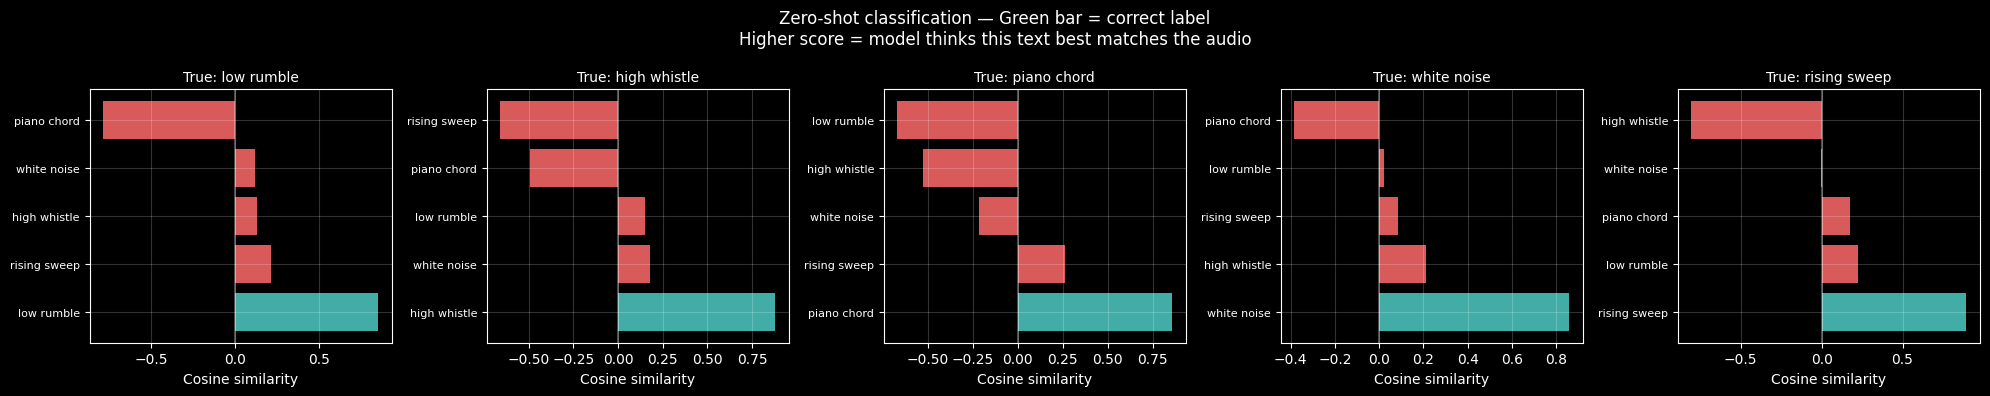

In [10]:
# --- Visualize classification confidences ---

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (true_label, audio) in enumerate(test_clips.items()):
    mel = log_mel_spectrogram(audio)
    scores = classify_zero_shot(mel, text_descriptions)

    labels_plot = list(scores.keys())
    values_plot = list(scores.values())
    bar_colors  = ['#4ECDC4' if l == true_label else '#FF6B6B' for l in labels_plot]

    axes[i].barh(range(len(labels_plot)), values_plot, color=bar_colors, alpha=0.85)
    axes[i].set_yticks(range(len(labels_plot)))
    axes[i].set_yticklabels([l[:12] for l in labels_plot], fontsize=8)
    axes[i].set_title(f'True: {true_label}', fontsize=10)
    axes[i].set_xlabel('Cosine similarity')
    axes[i].axvline(0, color='white', alpha=0.3)
    axes[i].grid(alpha=0.2)

plt.suptitle('Zero-shot classification — Green bar = correct label\n'
             'Higher score = model thinks this text best matches the audio',
             fontsize=12)
plt.tight_layout()
plt.show()

---
## Part 8: AF-CLAP → AF-Whisper — What Changed in AF3

Now that you understand CLAP deeply, here's the architectural story of Audio Flamingo:

In [11]:
story = """
┌─────────────────────────────────────────────────────────────────────────┐
│  From CLAP to AF-Whisper: the evolution across AF versions              │
│                                                                         │
│  AF1 (2024)                                                             │
│  └─ Audio encoder: CLAP (off-the-shelf, frozen)                        │
│     CLAP produces a single 512-dim vector per audio clip                │
│     Problem: one vector loses temporal structure                        │
│              can't handle long audio, can't localize events in time     │
│                                                                         │
│  AF2 (ICML 2025)                                                        │
│  └─ Audio encoder: AF-CLAP (retrained CLAP, finetuned)                 │
│     Better coverage (more audio types), still a single global vector    │
│     Problem: still loses temporal detail                                │
│                                                                         │
│  AF3 (NeurIPS 2025 Spotlight)                                           │
│  └─ Audio encoder: AF-Whisper (Whisper large-v3, retrained)             │
│     Produces 1500 vectors × 1280-dim (per 30s chunk)                    │
│     Each vector = one 20ms slice of audio                               │
│     The LLM sees the FULL temporal sequence, not just a summary         │
│                                                                         │
│  Why the switch?                                                        │
│                                                                         │
│  CLAP:        audio → [POOL] → 1 vector  (loses time)                  │
│  AF-Whisper:  audio → [NO POOL] → 1500 vectors  (keeps time)           │
│                                                                         │
│  For QA like "what happens at 2:34 in this recording?",                 │
│  you NEED temporal information — a single vector can't answer that.     │
│                                                                         │
│  The CLAP training principle (contrastive audio-text alignment)         │
│  is still used to PRETRAIN AF-Whisper — it's baked into the weights.   │
│  But the architecture shifts from "global pooling" to "sequence out".  │
└─────────────────────────────────────────────────────────────────────────┘
"""
print(story)

# Summary of where we are
pipeline = """
┌─────────────────────────────────────────────────────────────────────────┐
│  AF3 Pipeline — Modules 1-3 Complete                                    │
│                                                                         │
│  RAW AUDIO (waveform)                                                   │
│       │                                                                 │
│       ▼  Module 1 ✓                                                     │
│  LOG MEL SPECTROGRAM  (80, T)                                           │
│       │                                                                 │
│       ▼  Module 2 ✓                                                     │
│  AF-WHISPER ENCODER                                                     │
│  → 1500 audio embeddings × 1280-dim                                     │
│  (pretrained with CLAP-style contrastive loss ← Module 3 ✓)            │
│       │                                                                 │
│       ▼  Module 4 (next)                                                │
│  AUDIO PROJECTOR  (MLP: 1280 → 3584)                                   │
│  Adapts audio embeddings to LLM's input dimension                      │
│       │                                                                 │
│       ▼  Module 4                                                       │
│  QWEN-2.5 7B  (frozen during audio training)                           │
│  1500 audio tokens + text prompt → answer                              │
└─────────────────────────────────────────────────────────────────────────┘
"""
print(pipeline)


┌─────────────────────────────────────────────────────────────────────────┐
│  From CLAP to AF-Whisper: the evolution across AF versions              │
│                                                                         │
│  AF1 (2024)                                                             │
│  └─ Audio encoder: CLAP (off-the-shelf, frozen)                        │
│     CLAP produces a single 512-dim vector per audio clip                │
│     Problem: one vector loses temporal structure                        │
│              can't handle long audio, can't localize events in time     │
│                                                                         │
│  AF2 (ICML 2025)                                                        │
│  └─ Audio encoder: AF-CLAP (retrained CLAP, finetuned)                 │
│     Better coverage (more audio types), still a single global vector    │
│     Problem: still loses temporal detail                                │
│            

---
## Summary

Here's what you built and learned:

| Component | Role | Key idea |
|-----------|------|----------|
| NanoAudioEncoder | Audio → 128-dim vector | Conv + global avg pool + L2 normalize |
| NanoTextEncoder | Text → 128-dim vector | Word embeddings + MLP + L2 normalize |
| InfoNCE Loss | Pull matching pairs together | Diagonal cross-entropy on NxN similarity matrix |
| Temperature τ | Controls sharpness | Learned parameter, typically ~0.07 |
| Zero-shot classification | No labels needed | Nearest text to audio in embedding space |

**The key insight:** CLAP doesn't learn to classify. It learns a geometry — a shared space where audio and language meanings overlap. Classification is just nearest-neighbor search in that space.

**Next up: Module 4 — The LLaVA Pattern.** We'll take our AF-Whisper encoder, add a small MLP projector, and plug it into a frozen LLM (Qwen 0.5B). This is the complete AF3 architecture, just smaller.

---
## Exercises (before Module 4)

1. **Temperature sensitivity**: change `InfoNCELoss(temperature=0.5)` and `temperature=0.01`. How does the loss landscape change? Which trains faster? Which gets higher accuracy? This is a real hyperparameter choice in CLAP papers.

2. **Hard negatives**: the hardest training pairs for the model are those that are *almost* correct — similar-sounding concepts. Add a 6th concept: `'low piano note'` with audio `0.4 * sin(2*pi*110*t)` (a very low piano note). Does the model confuse it with `'low rumble'`? Why?

3. **Batch size effect**: InfoNCE loss quality depends on batch size — more negatives in the batch = harder contrastive problem = better learned representations. Try training with only 4 samples per batch (one concept at a time). What happens to the embedding space?

4. **Global pooling vs temporal**: our audio encoder uses `x.mean(dim=-1)` to collapse the time dimension. Replace it with `x[:, :, 0]` (take only the first time step). Does it still learn? What does this tell you about *why* AF3 switched from CLAP (global pooling) to AF-Whisper (no pooling)?